# Week 1 — Introduction to Machine Learning
**Course:** 21CSC305P Machine Learning · **Unit 1 – Introduction**

**Topics covered:** what & why of ML · supervised and unsupervised learning · polynomial curve fitting · probability theory
(discrete random variables, fundamental rules, Bayes' rule, independence & conditional independence, continuous random variables,
quantiles, mean & variance, probability densities, expectation & covariance).

**Practice tasks**
1. Devise a program to import, load and view a dataset
2. Create a program to display the summary and statistics of the dataset

### The dataset used in *every* week: Beijing PM2.5 air quality
Hourly readings from 1 Jan 2010 to 31 Dec 2014 (43,824 rows): **PM2.5 concentration** (µg/m³, US Embassy monitor) together with weather at Beijing airport —
dew point, temperature, pressure, wind direction, cumulated wind speed, hours of snow and rain.
Source: UCI Machine Learning Repository, *Beijing PM2.5 Data* (CC BY 4.0), Liang et al. (2015) *Proc. R. Soc. A* 471.
The file is downloaded once into `data/` by the shared helper `beijing_pm25.py`.

Why this data suits the whole course: it is real and messy (missing values, heavy-tailed, seasonal), it supports **regression** (how much PM2.5?), **classification** (polluted day?),
**clustering / PCA** (weather regimes), **sequence models** (pollution episodes persist from day to day → HMM) and **ensembles**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

import beijing_pm25 as bj          # shared loader (downloads the CSV on first use)

np.random.seed(42)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

hourly = bj.load_hourly()          # one row per hour
daily = bj.load_daily()            # one row per day (weather summaries + daily-mean PM2.5)
print(hourly.shape, daily.shape)

(43824, 8) (1826, 21)


## Part A — Theory in code

### A1. What is machine learning, and why?
Machine learning builds programs whose behaviour is **learned from data** instead of hand-coded. It is useful when the rules are
too complex to write down, when they change over time, or when we want to discover structure in data.

| | Supervised learning | Unsupervised learning |
|---|---|---|
| Data | inputs **x** *and* targets *t* | inputs **x** only |
| Goal | predict *t* for new **x** (regression / classification) | discover structure (clustering, density estimation, dimensionality reduction) |
| Beijing example | predict whether tomorrow's air is *polluted* from the weather | group days into weather regimes without any labels |

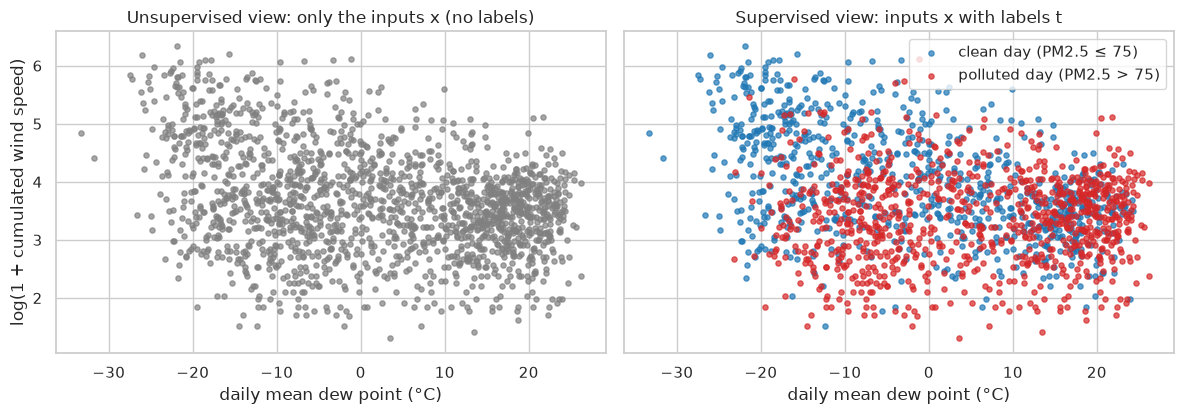

In [2]:
v = daily.dropna(subset=["pm25"])
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3), sharex=True, sharey=True)
ax[0].scatter(v["dew"], v["log_wind"], c="gray", s=14, alpha=.7); ax[0].set_title("Unsupervised view: only the inputs x (no labels)")
for k, (lab, c) in enumerate([("clean day (PM2.5 ≤ 75)", "tab:blue"), ("polluted day (PM2.5 > 75)", "tab:red")]):
    m = v["polluted"] == k; ax[1].scatter(v.loc[m, "dew"], v.loc[m, "log_wind"], c=c, s=14, alpha=.7, label=lab)
ax[1].set_title("Supervised view: inputs x with labels t"); ax[1].legend()
for a in ax: a.set_xlabel("daily mean dew point (°C)")
ax[0].set_ylabel("log(1 + cumulated wind speed)"); plt.tight_layout(); plt.show()

### A2. Polynomial curve fitting (Bishop §1.1)
Data are generated as $t = \sin(2\pi x) + \varepsilon$ with Gaussian noise (a synthetic example, so we know the truth). We fit
$y(x, \mathbf{w}) = \sum_{j=0}^{M} w_j x^j$ by minimising the sum-of-squares error
$E(\mathbf{w}) = \tfrac12 \sum_n \{y(x_n,\mathbf{w}) - t_n\}^2$.
Low $M$ **under-fits**, high $M$ **over-fits** (it passes through the noise).

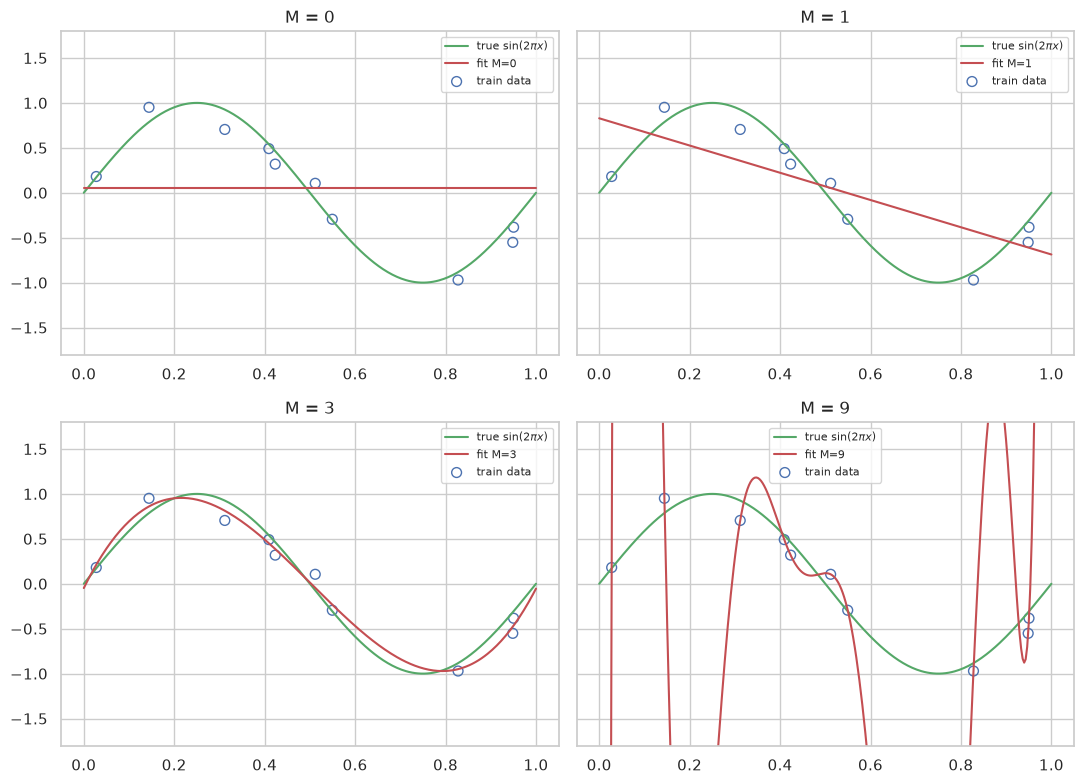

In [3]:
def make_data(N, noise=0.3, seed=0):
    r = np.random.default_rng(seed)
    x = np.sort(r.uniform(0, 1, N))
    return x, np.sin(2 * np.pi * x) + r.normal(0, noise, N)

x_train, t_train = make_data(10, seed=1)
x_test,  t_test  = make_data(100, seed=2)
x_line = np.linspace(0, 1, 300)

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=True)
for ax, M in zip(axes.ravel(), [0, 1, 3, 9]):
    w = np.polyfit(x_train, t_train, M)
    ax.plot(x_line, np.sin(2 * np.pi * x_line), "g", label=r"true $\sin(2\pi x)$")
    ax.plot(x_line, np.polyval(w, x_line), "r", label=f"fit M={M}")
    ax.scatter(x_train, t_train, facecolors="none", edgecolors="b", s=50, label="train data")
    ax.set_title(f"M = {M}"); ax.set_ylim(-1.8, 1.8); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

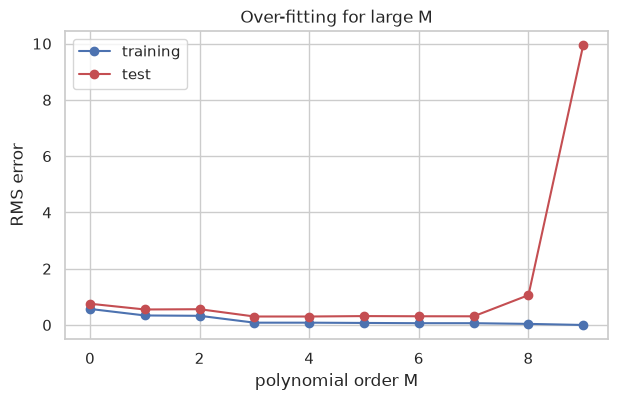

In [4]:
# Train vs test RMS error as a function of model complexity M
def rmse(w, x, t): return np.sqrt(np.mean((np.polyval(w, x) - t) ** 2))

Ms = range(0, 10)
tr, te = [], []
for M in Ms:
    w = np.polyfit(x_train, t_train, M)
    tr.append(rmse(w, x_train, t_train)); te.append(rmse(w, x_test, t_test))

plt.figure(figsize=(7, 4))
plt.plot(Ms, tr, "o-b", label="training"); plt.plot(Ms, te, "o-r", label="test")
plt.xlabel("polynomial order M"); plt.ylabel("RMS error"); plt.title("Over-fitting for large M")
plt.legend(); plt.show()

**Regularisation.** Adding a penalty $\tfrac{\lambda}{2}\|\mathbf{w}\|^2$ shrinks the weights and tames over-fitting
(closed form: $\mathbf{w} = (\lambda I + \Phi^\top\Phi)^{-1}\Phi^\top \mathbf{t}$). Below, M = 9 is refit for several $\ln\lambda$.

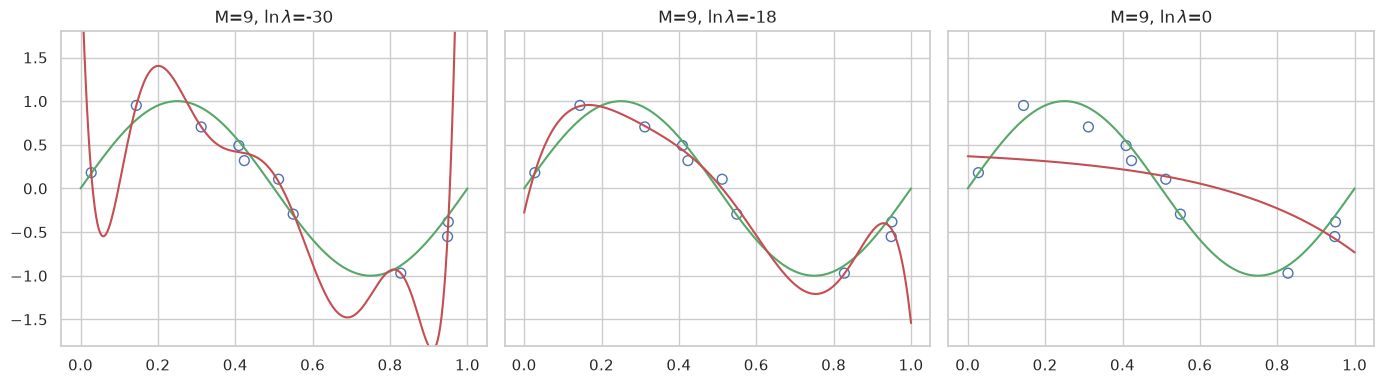

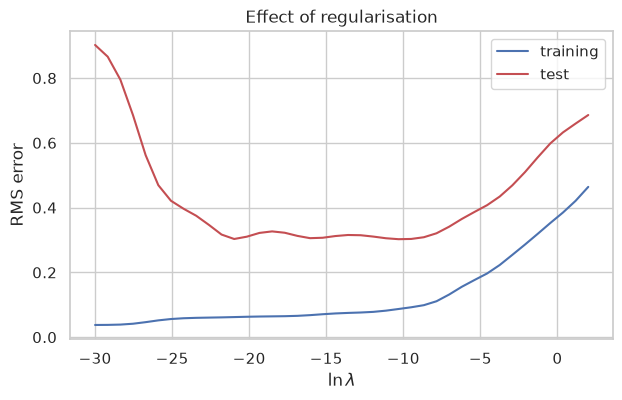

best ln(lambda) on test set: -10.3


In [5]:
def ridge_poly(x, t, M, lam):
    Phi = np.vander(x, M + 1, increasing=True)
    return np.linalg.solve(lam * np.eye(M + 1) + Phi.T @ Phi, Phi.T @ t)

def predict(w, x): return np.vander(x, len(w), increasing=True) @ w

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, ln_lam in zip(axes, [-30, -18, 0]):
    w = ridge_poly(x_train, t_train, 9, np.exp(ln_lam))
    ax.plot(x_line, np.sin(2 * np.pi * x_line), "g")
    ax.plot(x_line, predict(w, x_line), "r")
    ax.scatter(x_train, t_train, facecolors="none", edgecolors="b", s=50)
    ax.set_title(rf"M=9, $\ln\lambda$={ln_lam}"); ax.set_ylim(-1.8, 1.8)
plt.tight_layout(); plt.show()

lams = np.exp(np.linspace(-30, 2, 40))
tr = [np.sqrt(np.mean((predict(ridge_poly(x_train, t_train, 9, l), x_train) - t_train) ** 2)) for l in lams]
te = [np.sqrt(np.mean((predict(ridge_poly(x_train, t_train, 9, l), x_test) - t_test) ** 2)) for l in lams]
plt.figure(figsize=(7, 4)); plt.plot(np.log(lams), tr, "b", label="training"); plt.plot(np.log(lams), te, "r", label="test")
plt.xlabel(r"$\ln\lambda$"); plt.ylabel("RMS error"); plt.legend(); plt.title("Effect of regularisation"); plt.show()
print(f"best ln(lambda) on test set: {np.log(lams[np.argmin(te)]):.1f}")

**The same story on real data.** Daily temperature follows an annual cycle. We fit polynomials in the day of the year to just **30 random days from 2010–2012** and test on all days of **2013–2014**:
too low an order cannot follow the seasons, a very high order chases the day-to-day weather noise of the few training days (with 1,000+ training days this over-fitting would be much milder — more data tames variance).

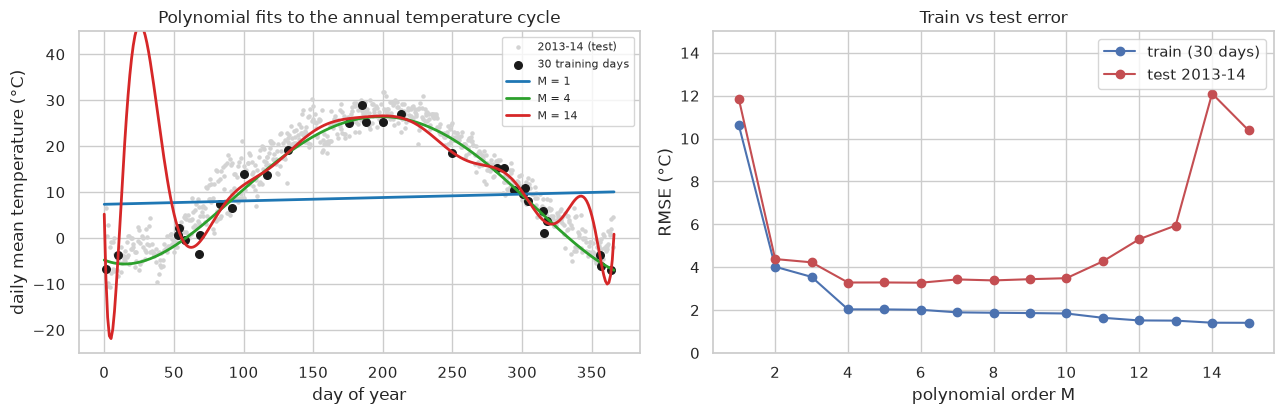

best order on test years: M = 6  (RMSE 3.28 °C)


In [6]:
from numpy.polynomial import Polynomial
tr_d = daily[daily.index.year <= 2012].sample(30, random_state=2); te_d = daily[daily.index.year >= 2013]
doy = lambda d: d["dayofyear"].values / 366.0
orders = range(1, 16); e_tr, e_te = [], []
for M in orders:
    p = Polynomial.fit(doy(tr_d), tr_d["temp"].values, M)
    e_tr.append(np.sqrt(np.mean((p(doy(tr_d)) - tr_d["temp"]) ** 2))); e_te.append(np.sqrt(np.mean((p(doy(te_d)) - te_d["temp"]) ** 2)))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
ax[0].scatter(te_d["dayofyear"], te_d["temp"], s=5, c="lightgray", label="2013-14 (test)"); ax[0].scatter(doy(tr_d) * 366, tr_d["temp"], s=30, c="k", label="30 training days")
g = np.linspace(0, 1, 300)
for M, c in [(1, "tab:blue"), (4, "tab:green"), (14, "tab:red")]: ax[0].plot(g * 366, Polynomial.fit(doy(tr_d), tr_d["temp"].values, M)(g), c=c, lw=2, label=f"M = {M}")
ax[0].set(xlabel="day of year", ylabel="daily mean temperature (°C)", title="Polynomial fits to the annual temperature cycle", ylim=(-25, 45)); ax[0].legend(fontsize=8)
ax[1].plot(orders, e_tr, "o-b", label="train (30 days)"); ax[1].plot(orders, e_te, "o-r", label="test 2013-14"); ax[1].set(xlabel="polynomial order M", ylabel="RMSE (°C)", title="Train vs test error", ylim=(0, 15)); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"best order on test years: M = {list(orders)[int(np.argmin(e_te))]}  (RMSE {min(e_te):.2f} °C)")

### A3. Discrete random variables, Bayes' rule
Fundamental rules: **sum rule** $p(X)=\sum_Y p(X,Y)$, **product rule** $p(X,Y)=p(Y|X)p(X)$, and therefore
**Bayes' rule**

$$p(Y\mid X)=\frac{p(X\mid Y)\,p(Y)}{p(X)} .$$

*Example 1 – a medical test.* Disease prevalence 1 %, sensitivity $p(+|D)=0.90$, specificity $p(-|\neg D)=0.95$.
What is $p(D\mid +)$? Computed analytically and checked by Monte-Carlo simulation.

p(+)      = 0.0585
p(D | +)  = 0.1538   <- far lower than the 90% sensitivity!
simulated p(D | +) = 0.1537


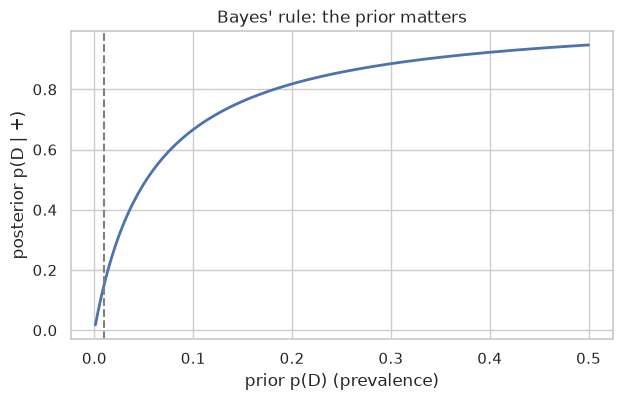

In [7]:
p_d, sens, spec = 0.01, 0.90, 0.95
p_pos = sens * p_d + (1 - spec) * (1 - p_d)          # sum rule
posterior = sens * p_d / p_pos                        # Bayes rule
print(f"p(+)      = {p_pos:.4f}")
print(f"p(D | +)  = {posterior:.4f}   <- far lower than the 90% sensitivity!")

rng = np.random.default_rng(0)
N = 2_000_000
disease = rng.random(N) < p_d
positive = np.where(disease, rng.random(N) < sens, rng.random(N) > spec)
print(f"simulated p(D | +) = {disease[positive].mean():.4f}")

prev = np.linspace(0.001, 0.5, 200)
post = sens * prev / (sens * prev + (1 - spec) * (1 - prev))
plt.figure(figsize=(7, 4)); plt.plot(prev, post, lw=2); plt.axvline(p_d, ls="--", c="gray")
plt.xlabel("prior p(D) (prevalence)"); plt.ylabel("posterior p(D | +)")
plt.title("Bayes' rule: the prior matters"); plt.show()

*Example 2 – Beijing.* Let $Y$ = "the day is polluted" (PM2.5 > 75 µg/m³) and $X$ = "calm or south-easterly wind"
(*stagnant air*). What is $p(Y|X)$ — the chance that a stagnant day is polluted? We obtain it from Bayes' rule using $p(X|Y)$, $p(Y)$ and $p(X)$ and confirm it by direct counting.

p(polluted) = 0.526   p(stagnant) = 0.560   p(stagnant | polluted) = 0.740
Bayes' rule      p(polluted | stagnant) = 0.695
direct counting  p(polluted | stagnant) = 0.695
                 p(polluted | not stagnant) = 0.311


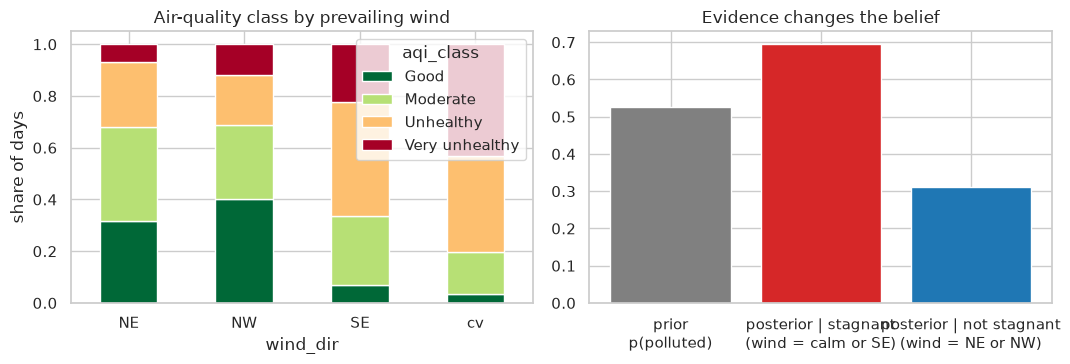

In [8]:
v = daily.dropna(subset=["pm25"]).copy()
Y = v["polluted"] == 1                                  # polluted day
X = v["wind_dir"].isin(["cv", "SE"])                    # stagnant air: calm or south-east wind

p_Y, p_X, p_X_given_Y = Y.mean(), X.mean(), X[Y].mean()
bayes = p_X_given_Y * p_Y / p_X
print(f"p(polluted) = {p_Y:.3f}   p(stagnant) = {p_X:.3f}   p(stagnant | polluted) = {p_X_given_Y:.3f}")
print(f"Bayes' rule      p(polluted | stagnant) = {bayes:.3f}")
print(f"direct counting  p(polluted | stagnant) = {Y[X].mean():.3f}")
print(f"                 p(polluted | not stagnant) = {Y[~X].mean():.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
pd.crosstab(v["wind_dir"], v["aqi_class"], normalize="index").plot.bar(stacked=True, ax=ax[0], rot=0, colormap="RdYlGn_r"); ax[0].set(ylabel="share of days", title="Air-quality class by prevailing wind")
ax[1].bar(["prior\np(polluted)", "posterior | stagnant\n(wind = calm or SE)", "posterior | not stagnant\n(wind = NE or NW)"], [p_Y, Y[X].mean(), Y[~X].mean()], color=["gray", "tab:red", "tab:blue"]); ax[1].set_title("Evidence changes the belief")
plt.tight_layout(); plt.show()

### A4. Independence and conditional independence
$X\perp Y \iff p(X,Y)=p(X)p(Y)$; $X\perp Y\mid Z \iff p(X,Y|Z)=p(X|Z)p(Y|Z)$.
Two variables can be **dependent marginally but independent given a common cause**.
Here a coin is picked at random (fair or biased, 50/50) and flipped twice: the flips are independent given the coin, yet dependent overall.

In [9]:
rng = np.random.default_rng(1)
N = 400_000
coin_biased = rng.random(N) < 0.5                       # Z
p_heads = np.where(coin_biased, 0.9, 0.5)
f1 = rng.random(N) < p_heads                            # X
f2 = rng.random(N) < p_heads                            # Y

def joint_vs_product(a, b, label):
    pa, pb, pab = a.mean(), b.mean(), (a & b).mean()
    print(f"{label:<28} p(X,Y)={pab:.4f}  p(X)p(Y)={pa*pb:.4f}  -> {'independent' if abs(pab-pa*pb)<2e-3 else 'DEPENDENT'}")

joint_vs_product(f1, f2, "marginal")
joint_vs_product(f1[coin_biased], f2[coin_biased], "given biased coin")
joint_vs_product(f1[~coin_biased], f2[~coin_biased], "given fair coin")

marginal                     p(X,Y)=0.5300  p(X)p(Y)=0.4900  -> DEPENDENT
given biased coin            p(X,Y)=0.8092  p(X)p(Y)=0.8091  -> independent
given fair coin              p(X,Y)=0.2501  p(X)p(Y)=0.2499  -> independent


A real-data check: *"today is polluted"* and *"it rained today"* are **dependent overall** (rain days are more often polluted — rain happens in the humid summer/south-easterly air masses that also trap pollution).
Conditioning on the prevailing wind (a common cause) removes the dependence for NW winds, but **not** for SE winds — real data are rarely as clean as the coin example, and the wind direction explains only part of the link.

In [10]:
rain = v["rain_h"] > 0
def dep(mask, label):
    a, b = Y[mask], rain[mask]; print(f"{label:<30} p(polluted)={a.mean():.3f}  p(polluted | rain)={a[b].mean():.3f}  p(polluted | no rain)={a[~b].mean():.3f}   (n={mask.sum()})")
dep(pd.Series(True, index=v.index), "all days")
for w in ["cv", "SE", "NW", "NE"]: dep(v["wind_dir"] == w, f"wind = {w}")

all days                       p(polluted)=0.526  p(polluted | rain)=0.628  p(polluted | no rain)=0.499   (n=1753)
wind = cv                      p(polluted)=0.803  p(polluted | rain)=0.745  p(polluted | no rain)=0.819   (n=213)
wind = SE                      p(polluted)=0.664  p(polluted | rain)=0.751  p(polluted | no rain)=0.632   (n=769)
wind = NW                      p(polluted)=0.310  p(polluted | rain)=0.318  p(polluted | no rain)=0.309   (n=683)
wind = NE                      p(polluted)=0.318  p(polluted | rain)=0.409  p(polluted | no rain)=0.288   (n=88)


### A5. Continuous random variables
A density $p(x)\ge 0$ with $\int p(x)dx=1$, CDF $P(x)=\int_{-\infty}^x p$, **quantile** $=P^{-1}(q)$.
For $\mathcal N(\mu,\sigma^2)$: $\mathbb E[x]=\mu$, $\mathrm{var}[x]=\sigma^2$.

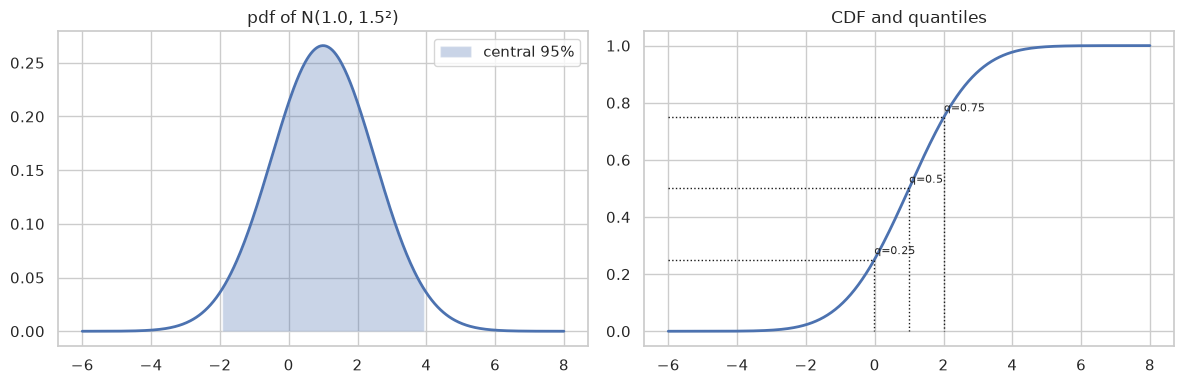

quantiles (25/50/75%):  theory [-0.012  1.     2.012]   sample [-0.014  1.     2.013]
mean  theory 1.0   sample 1.001
var   theory 2.25  sample 2.246
E[x^2] = var + mean^2 = 3.250   sample 3.248


In [11]:
mu, sigma = 1.0, 1.5
xs = np.linspace(-6, 8, 500)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(xs, stats.norm.pdf(xs, mu, sigma), lw=2)
lo, hi = stats.norm.ppf([0.025, 0.975], mu, sigma)
ax[0].fill_between(xs, stats.norm.pdf(xs, mu, sigma), where=(xs >= lo) & (xs <= hi), alpha=0.3, label="central 95%")
ax[0].set_title(f"pdf of N({mu}, {sigma}²)"); ax[0].legend()
ax[1].plot(xs, stats.norm.cdf(xs, mu, sigma), lw=2)
for q in [0.25, 0.5, 0.75]:
    xq = stats.norm.ppf(q, mu, sigma)
    ax[1].plot([xs[0], xq, xq], [q, q, 0], "k:", lw=1); ax[1].text(xq, q + 0.02, f"q={q}", fontsize=8)
ax[1].set_title("CDF and quantiles")
plt.tight_layout(); plt.show()

s = np.random.default_rng(3).normal(mu, sigma, 200_000)
print(f"quantiles (25/50/75%):  theory {stats.norm.ppf([.25,.5,.75], mu, sigma).round(3)}   sample {np.quantile(s, [.25,.5,.75]).round(3)}")
print(f"mean  theory {mu}   sample {s.mean():.3f}")
print(f"var   theory {sigma**2}  sample {s.var():.3f}")
print(f"E[x^2] = var + mean^2 = {sigma**2 + mu**2:.3f}   sample {np.mean(s**2):.3f}")

**Which density describes PM2.5?** Concentrations are positive and right-skewed, so a Gaussian is a poor model, but $\ln(\text{PM2.5})$ is much closer to Gaussian — i.e. PM2.5 is roughly **log-normal**.
We compare both fits to the 41,757 valid hourly readings and check their quantiles: the Gaussian fit is clearly wrong in the lower tail (it predicts *negative* concentrations), while the log-normal captures the bulk of the distribution but over-estimates the very extreme upper tail.

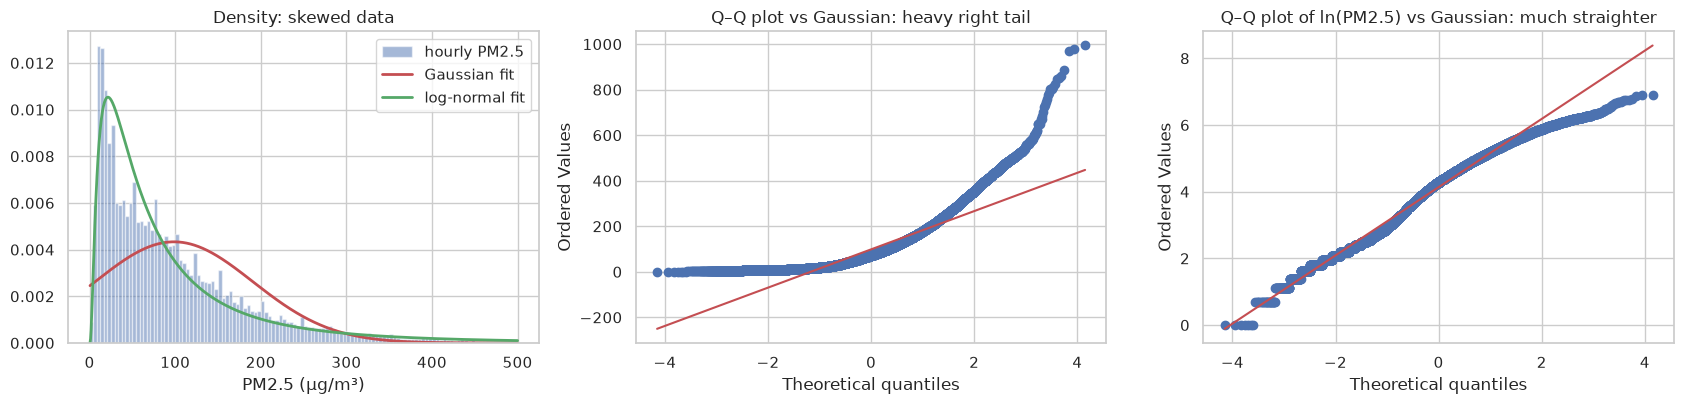

     empirical  Gaussian fit  log-normal fit
5%        10.0         -52.8            11.4
25%       29.0          36.5            31.1
50%       72.0          98.6            62.5
75%      137.0         160.7           125.6
95%      284.0         250.0           342.5
99%      420.0         312.8           693.0

mean = 98.6, variance = 8473, skewness = 1.80   |   ln(PM2.5): mean = 4.14, sd = 1.03, skewness = -0.36
WHO 24-h guideline: 15 µg/m³ (annual 5). Share of hours above 75 µg/m³ = 48.5%;  above 150 = 21.5%


In [12]:
pm = hourly["pm25"].dropna(); lp = np.log(pm.clip(lower=1))
mu_n, sd_n = pm.mean(), pm.std(); mu_l, sd_l = lp.mean(), lp.std()
xs = np.linspace(0.5, 500, 800)
fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))
ax[0].hist(pm, bins=120, range=(0, 500), density=True, alpha=.5, label="hourly PM2.5")
ax[0].plot(xs, stats.norm.pdf(xs, mu_n, sd_n), "r", lw=2, label="Gaussian fit"); ax[0].plot(xs, stats.lognorm.pdf(xs, sd_l, scale=np.exp(mu_l)), "g", lw=2, label="log-normal fit")
ax[0].set(xlabel="PM2.5 (µg/m³)", title="Density: skewed data"); ax[0].legend()
stats.probplot(pm, dist="norm", plot=ax[1]); ax[1].set_title("Q–Q plot vs Gaussian: heavy right tail")
stats.probplot(lp, dist="norm", plot=ax[2]); ax[2].set_title("Q–Q plot of ln(PM2.5) vs Gaussian: much straighter")
plt.tight_layout(); plt.show()

qs = [.05, .25, .5, .75, .95, .99]
print(pd.DataFrame({"empirical": np.quantile(pm, qs), "Gaussian fit": stats.norm.ppf(qs, mu_n, sd_n), "log-normal fit": stats.lognorm.ppf(qs, sd_l, scale=np.exp(mu_l))}, index=[f"{int(q*100)}%" for q in qs]).round(1))
print(f"\nmean = {pm.mean():.1f}, variance = {pm.var():.0f}, skewness = {pm.skew():.2f}   |   ln(PM2.5): mean = {lp.mean():.2f}, sd = {lp.std():.2f}, skewness = {lp.skew():.2f}")
print(f"WHO 24-h guideline: 15 µg/m³ (annual 5). Share of hours above 75 µg/m³ = {(pm > 75).mean():.1%};  above 150 = {(pm > 150).mean():.1%}")

### A6. Expectation and covariance
$\mathrm{cov}[x,y]=\mathbb E[xy]-\mathbb E[x]\mathbb E[y]$. For a multivariate Gaussian the covariance matrix $\Sigma$ controls the
orientation and spread of the density contours (ellipses along the eigenvectors of $\Sigma$).
Daily mean temperature and dew point in Beijing are strongly (positively) correlated — warm air holds more moisture.

sample mean       : [12.45  1.82]
sample covariance :
 [[133.6  148.39]
 [148.39 200.73]]
correlation coeff : 0.906
E[xy] - E[x]E[y]  : 148.31   (= cov[x,y])


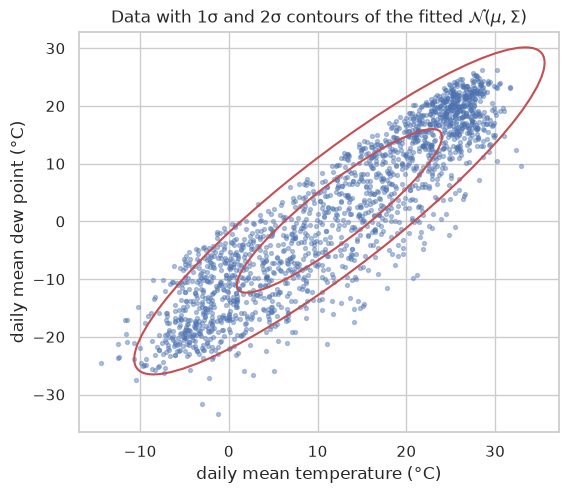

In [13]:
from matplotlib.patches import Ellipse
P = daily[["temp", "dew"]].dropna().values
mean, Sigma = P.mean(0), np.cov(P.T)
print("sample mean       :", mean.round(2))
print("sample covariance :\n", Sigma.round(2))
print("correlation coeff : %.3f" % np.corrcoef(P.T)[0, 1])
print("E[xy] - E[x]E[y]  : %.2f   (= cov[x,y])" % (np.mean(P[:, 0] * P[:, 1]) - P[:, 0].mean() * P[:, 1].mean() ))

vals, vecs = np.linalg.eigh(Sigma); angle = np.degrees(np.arctan2(vecs[1, 1], vecs[0, 1]))
fig, ax = plt.subplots(figsize=(6.2, 5.2))
ax.scatter(P[:, 0], P[:, 1], s=8, alpha=.4)
for k in (1, 2):
    ax.add_patch(Ellipse(mean, 2 * k * np.sqrt(vals[1]), 2 * k * np.sqrt(vals[0]), angle=angle, fill=False, ec="r", lw=1.5))
ax.set(xlabel="daily mean temperature (°C)", ylabel="daily mean dew point (°C)", title=r"Data with 1σ and 2σ contours of the fitted $\mathcal{N}(\mu,\Sigma)$"); plt.show()

---
## Part B — Practice

## Practice 1 — Import, load and view a dataset
Steps: (i) obtain the CSV, (ii) import it with `pandas.read_csv`, (iii) fix types (build a timestamp from the year/month/day/hour columns, mark `NA` as missing), (iv) view it in table and graphical form.

In [14]:
# 1. obtain the file (downloaded once into ./data by the helper; skipped if it already exists)
csv_path = bj._download()
print("file:", csv_path, f"({Path(csv_path).stat().st_size / 1e6:.1f} MB)")

# 2. import: the raw file as it is on disk – note the 'NA' strings for missing PM2.5
raw = pd.read_csv(csv_path)
print("\nraw shape:", raw.shape); display(raw.head())
print("\ndtypes before cleaning:"); print(raw.dtypes.to_string())

file: data/beijing_pm25.csv (2.0 MB)

raw shape: (43824, 13)


,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0



dtypes before cleaning:
No         int64
year       int64
month      int64
day        int64
hour       int64
pm2.5    float64
DEWP       int64
TEMP     float64
PRES     float64
cbwd         str
Iws      float64
Is         int64
Ir         int64


In [15]:
# 3. load properly: NA → NaN, one DatetimeIndex built from year/month/day/hour, tidy column names
df = pd.read_csv(csv_path, na_values="NA")
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])
df = (df.rename(columns={"pm2.5": "pm25", "DEWP": "dew", "TEMP": "temp", "PRES": "pres", "cbwd": "wind_dir", "Iws": "wind_speed", "Is": "snow_h", "Ir": "rain_h"})
        .set_index("datetime").drop(columns=["No", "year", "month", "day", "hour"]))
assert df.equals(hourly), "same result as the shared helper bj.load_hourly()"
print("covers", df.index.min(), "→", df.index.max(), f"| {len(df):,} hourly rows, regular 1-hour spacing: {(df.index.to_series().diff().dropna() == pd.Timedelta('1h')).all()}")

covers 2010-01-01 00:00:00 → 2014-12-31 23:00:00 | 43,824 hourly rows, regular 1-hour spacing: True


In [16]:
# 4. view the data
print("shape  :", df.shape); print("columns:", list(df.columns))
display(df.head()); display(df.tail(3)); display(df.sample(5, random_state=0).sort_index())
print(); df.info()

shape  : (43824, 8)
columns: ['pm25', 'dew', 'temp', 'pres', 'wind_dir', 'wind_speed', 'snow_h', 'rain_h']


,pm25,dew,temp,pres,wind_dir,wind_speed,snow_h,rain_h
datetime,,,,,,,,
2010-01-01 00:00:00,NaN,-21,-11.0,1021.0,NW,1.79,0,0
2010-01-01 01:00:00,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2010-01-01 02:00:00,NaN,-21,-11.0,1019.0,NW,6.71,0,0
2010-01-01 03:00:00,NaN,-21,-14.0,1019.0,NW,9.84,0,0
2010-01-01 04:00:00,NaN,-20,-12.0,1018.0,NW,12.97,0,0


,pm25,dew,temp,pres,wind_dir,wind_speed,snow_h,rain_h
datetime,,,,,,,,
2014-12-31 21:00:00,10.0,-22,-3.0,1034.0,NW,242.70,0,0
2014-12-31 22:00:00,8.0,-22,-4.0,1034.0,NW,246.72,0,0
2014-12-31 23:00:00,12.0,-21,-3.0,1034.0,NW,249.85,0,0


,pm25,dew,temp,pres,wind_dir,wind_speed,snow_h,rain_h
datetime,,,,,,,,
2010-11-25 23:00:00,168.0,-10,-3.0,1024.0,NW,1.79,0,0
2013-01-18 09:00:00,82.0,-12,-8.0,1029.0,NW,6.26,0,0
2013-01-27 01:00:00,307.0,-8,-5.0,1030.0,NE,0.89,0,0
2014-05-20 04:00:00,197.0,15,18.0,1003.0,NW,1.79,0,0
2014-11-06 17:00:00,6.0,-13,9.0,1030.0,NE,59.90,0,0



<class 'pandas.DataFrame'>
DatetimeIndex: 43824 entries, 2010-01-01 00:00:00 to 2014-12-31 23:00:00
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pm25        41757 non-null  float64
 1   dew         43824 non-null  int64  
 2   temp        43824 non-null  float64
 3   pres        43824 non-null  float64
 4   wind_dir    43824 non-null  str    
 5   wind_speed  43824 non-null  float64
 6   snow_h      43824 non-null  int64  
 7   rain_h      43824 non-null  int64  
dtypes: float64(4), int64(3), str(1)
memory usage: 3.0 MB


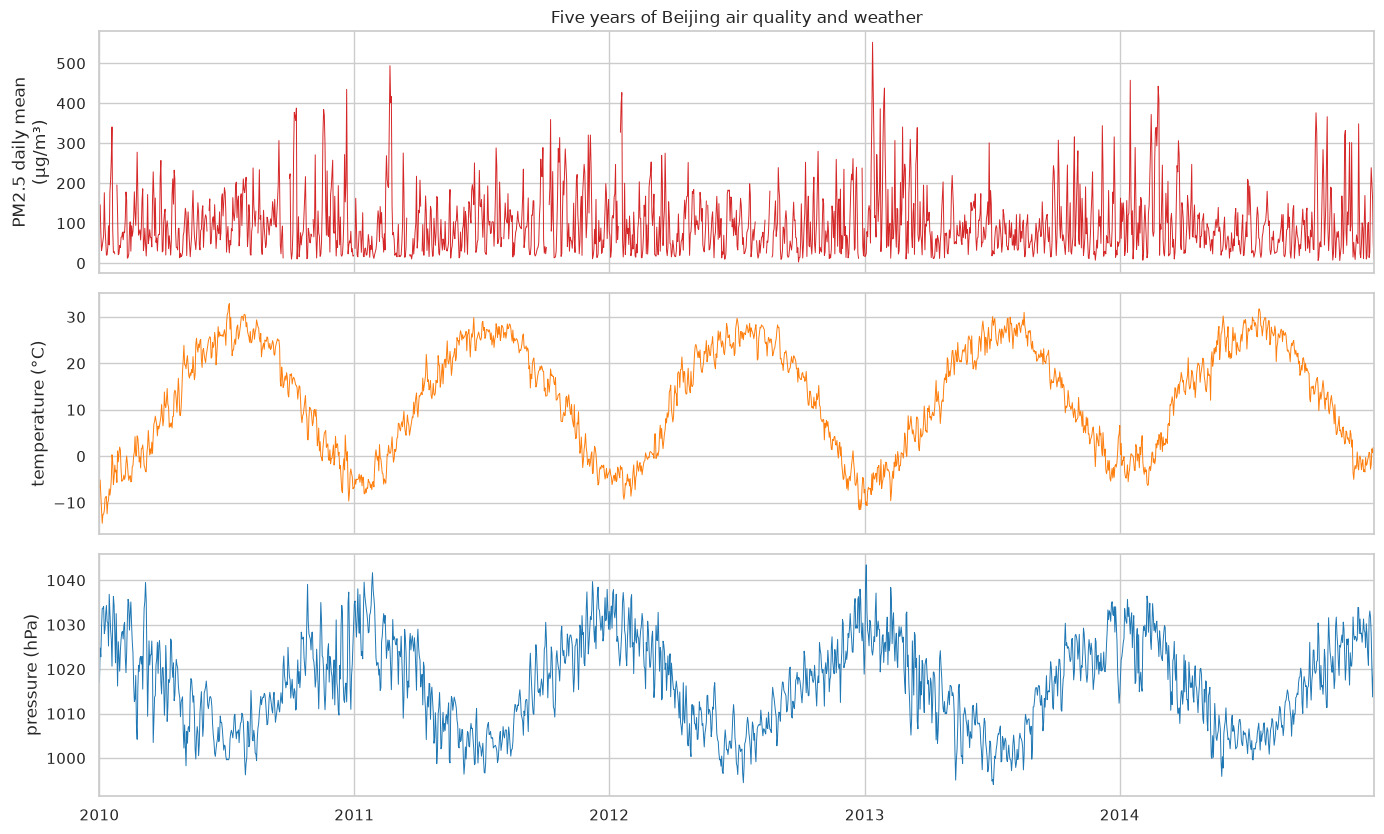

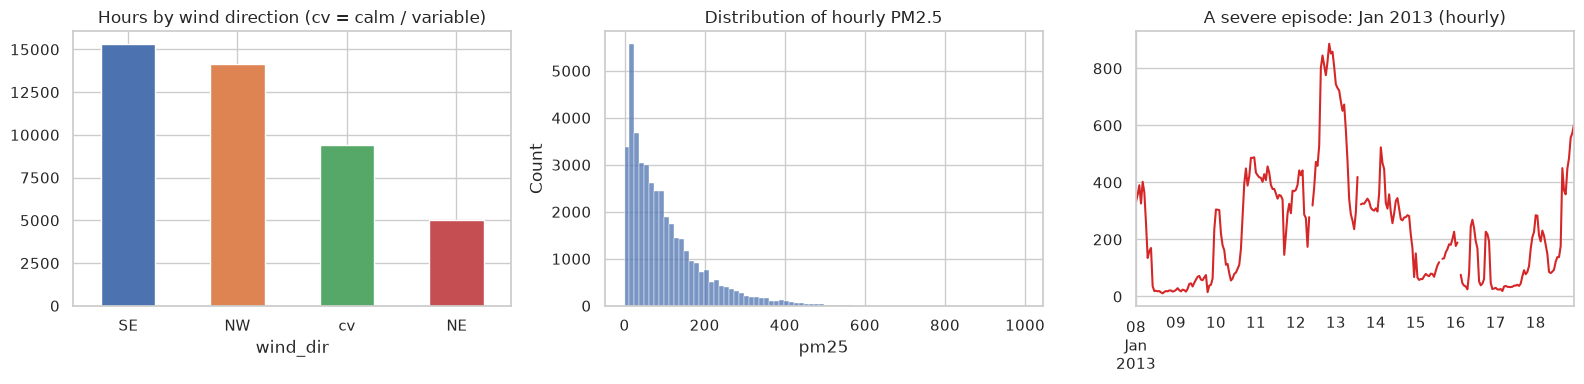

In [17]:
# 5. view it graphically
fig, ax = plt.subplots(3, 1, figsize=(14, 8.5), sharex=True)
df["pm25"].resample("D").mean().plot(ax=ax[0], lw=.7, color="tab:red"); ax[0].set_ylabel("PM2.5 daily mean\n(µg/m³)"); ax[0].set_title("Five years of Beijing air quality and weather")
df["temp"].resample("D").mean().plot(ax=ax[1], lw=.7, color="tab:orange"); ax[1].set_ylabel("temperature (°C)")
df["pres"].resample("D").mean().plot(ax=ax[2], lw=.7, color="tab:blue"); ax[2].set_ylabel("pressure (hPa)"); ax[2].set_xlabel("")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
df["wind_dir"].value_counts().plot.bar(ax=ax[0], rot=0, color=sns.color_palette()[:4]); ax[0].set_title("Hours by wind direction (cv = calm / variable)")
sns.histplot(df["pm25"].dropna(), bins=80, ax=ax[1]); ax[1].set_title("Distribution of hourly PM2.5")
df.loc["2013-01-08":"2013-01-18", "pm25"].plot(ax=ax[2], color="tab:red"); ax[2].set_title("A severe episode: Jan 2013 (hourly)"); ax[2].set_xlabel("")
plt.tight_layout(); plt.show()

## Practice 2 — Summary and statistics of the dataset
A reusable `summarize()` function reports: structure, missing values, duplicates, descriptive statistics
(count, mean, std, min, quartiles, max), skewness & kurtosis, categorical summaries, outliers (1.5·IQR rule) and per-group statistics, followed by plots.

In [18]:
def summarize(df, target=None):
    num = df.select_dtypes("number")
    print("=" * 60); print(f"Rows: {len(df)}   Columns: {df.shape[1]}   Duplicated rows: {df.duplicated().sum()}"); print("=" * 60)
    print("\n-- dtypes & missing values --")
    display(pd.DataFrame({"dtype": df.dtypes, "missing": df.isna().sum(), "missing %": (df.isna().mean() * 100).round(2), "unique": df.nunique()}))
    print("\n-- descriptive statistics (numeric) --")
    display(num.describe().T.assign(median=num.median(), var=num.var(), skew=num.skew(), kurtosis=num.kurt(),
                                   range=num.max() - num.min()).round(3))
    cat = df.select_dtypes(exclude="number")
    if not cat.empty:
        print("\n-- categorical columns --"); display(cat.describe().T)
    q1, q3 = num.quantile(.25), num.quantile(.75); iqr = q3 - q1
    outliers = ((num < q1 - 1.5 * iqr) | (num > q3 + 1.5 * iqr)).sum()
    print("\n-- outliers by 1.5*IQR rule --"); display(outliers.rename("n_outliers").to_frame().T)
    if target is not None:
        print(f"\n-- mean of each numeric feature by '{target}' --"); display(df.groupby(target, observed=True).mean(numeric_only=True).round(2))

summarize(df, target="wind_dir")

Rows: 43824   Columns: 8   Duplicated rows: 14

-- dtypes & missing values --


,dtype,missing,missing %,unique
pm25,float64,2067,4.72,581
dew,int64,0,0.00,69
temp,float64,0,0.00,64
pres,float64,0,0.00,60
wind_dir,str,0,0.00,4
wind_speed,float64,0,0.00,2788
snow_h,int64,0,0.00,28
rain_h,int64,0,0.00,37



-- descriptive statistics (numeric) --


,count,mean,std,min,25%,50%,75%,max,median,var,skew,kurtosis,range
pm25,41757.0,98.613,92.050,0.00,29.00,72.00,137.00,994.0,72.00,8473.274,1.802,4.769,994.00
dew,43824.0,1.817,14.433,-40.00,-10.00,2.00,15.00,28.0,2.00,208.324,-0.152,-1.195,68.00
temp,43824.0,12.449,12.199,-19.00,2.00,14.00,23.00,42.0,14.00,148.806,-0.163,-1.111,61.00
pres,43824.0,1016.448,10.269,991.00,1008.00,1016.00,1025.00,1046.0,1016.00,105.446,0.098,-0.846,55.00
wind_speed,43824.0,23.889,50.011,0.45,1.79,5.37,21.91,585.6,5.37,2501.064,4.298,23.421,585.15
snow_h,43824.0,0.053,0.760,0.00,0.00,0.00,0.00,27.0,0.00,0.578,19.484,449.082,27.00
rain_h,43824.0,0.195,1.416,0.00,0.00,0.00,0.00,36.0,0.00,2.005,11.662,174.425,36.00



-- categorical columns --


,count,unique,top,freq
wind_dir,43824,4,SE,15290



-- outliers by 1.5*IQR rule --


,pm25,dew,temp,pres,wind_speed,snow_h,rain_h
n_outliers,1773,0,0,0,5101,368,1808



-- mean of each numeric feature by 'wind_dir' --


,pm25,dew,temp,pres,wind_speed,snow_h,rain_h
wind_dir,,,,,,,
NE,90.18,0.33,10.28,1018.35,7.81,0.04,0.33
NW,70.13,-5.24,7.67,1019.86,49.88,0.03,0.27
SE,110.82,7.30,17.64,1012.93,18.44,0.09,0.12
cv,126.15,4.32,12.34,1016.02,2.15,0.03,0.14


### Missing values — are they random?

missing PM2.5 readings: 2067 of 43824 (4.7%)


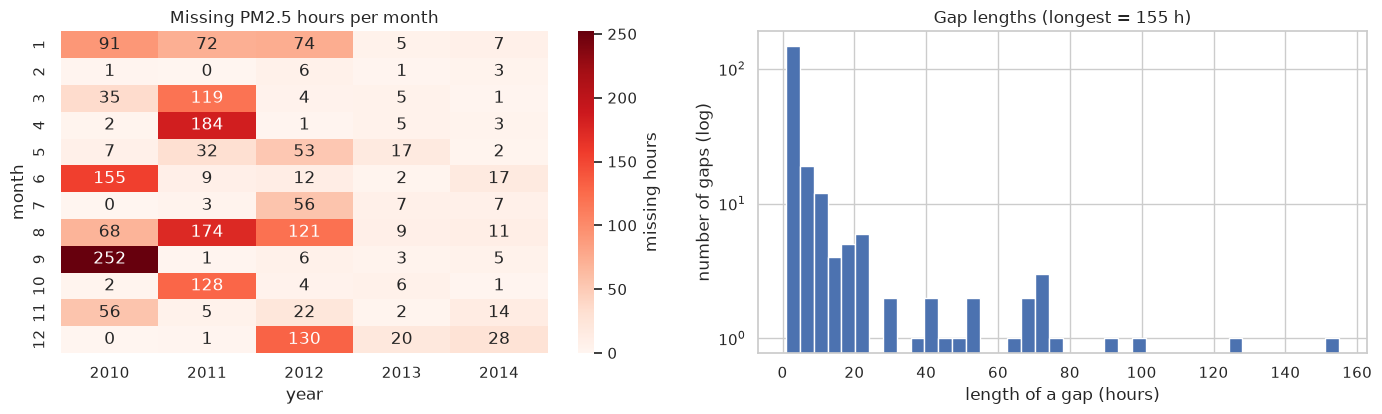

→ gaps are clustered (long outages), not scattered at random, so we aggregate to daily means and require ≥ 12 valid hours per day.


In [19]:
miss = df["pm25"].isna()
print(f"missing PM2.5 readings: {miss.sum()} of {len(df)} ({miss.mean():.1%})")
by_month = miss.groupby([df.index.year, df.index.month]).sum().unstack(0)
run = miss.astype(int).groupby((~miss).cumsum()).sum()
fig, ax = plt.subplots(1, 2, figsize=(14, 4.3))
sns.heatmap(by_month, cmap="Reds", annot=True, fmt="d", ax=ax[0], cbar_kws={"label": "missing hours"}); ax[0].set(xlabel="year", ylabel="month", title="Missing PM2.5 hours per month")
ax[1].hist(run[run > 0], bins=40, log=True); ax[1].set(xlabel="length of a gap (hours)", ylabel="number of gaps (log)", title=f"Gap lengths (longest = {run.max()} h)")
plt.tight_layout(); plt.show()
print("→ gaps are clustered (long outages), not scattered at random, so we aggregate to daily means and require ≥ 12 valid hours per day.")

### Distribution, skewness and transformation

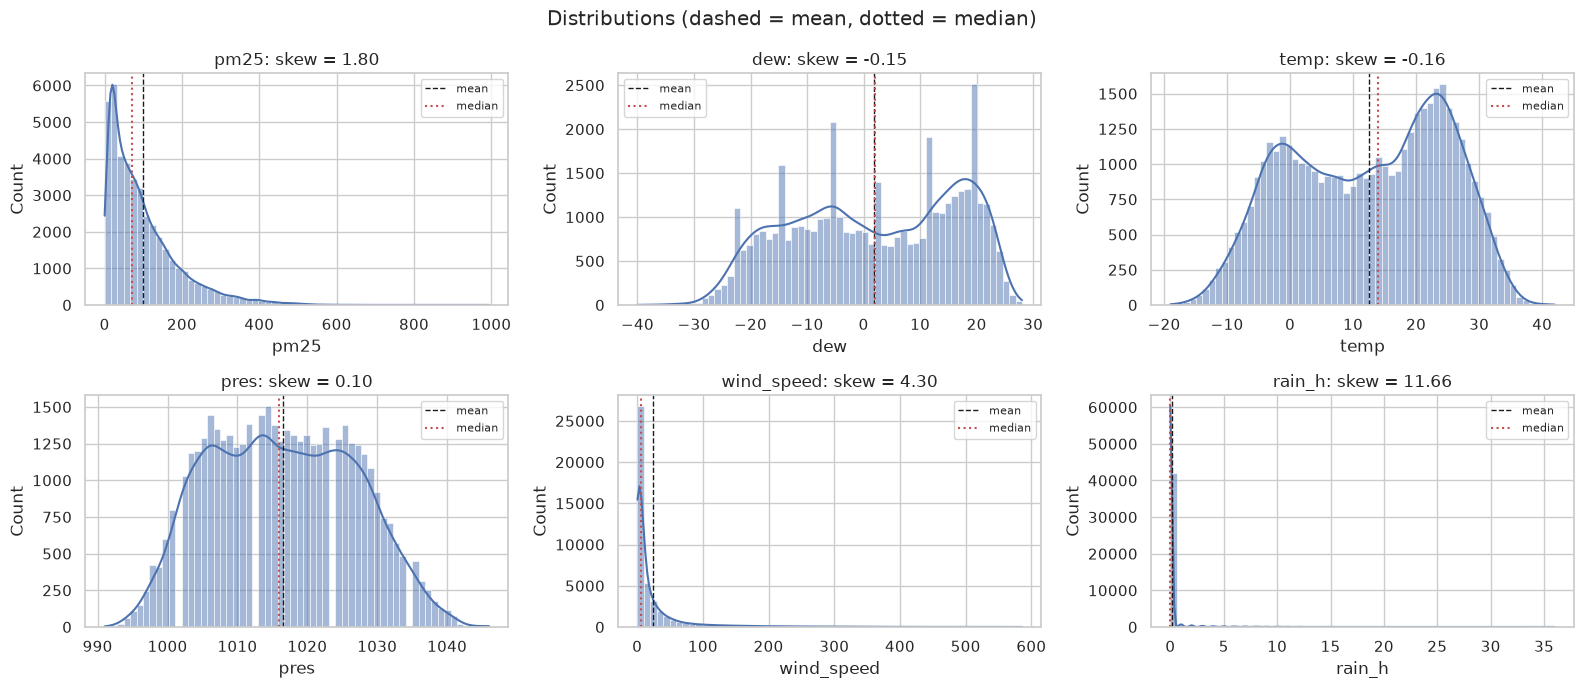

PM2.5 skewness 1.80 → ln(PM2.5) skewness -0.36  (a log transform makes it nearly symmetric; used for regression in later weeks)


In [20]:
num = df.select_dtypes("number")
fig, ax = plt.subplots(2, 3, figsize=(16, 7))
for a, col in zip(ax.ravel(), ["pm25", "dew", "temp", "pres", "wind_speed", "rain_h"]):
    sns.histplot(num[col].dropna(), bins=60, kde=True, ax=a); a.axvline(num[col].mean(), c="k", ls="--", lw=1, label="mean"); a.axvline(num[col].median(), c="r", ls=":", lw=1.5, label="median")
    a.set_title(f"{col}: skew = {num[col].skew():.2f}"); a.legend(fontsize=8)
plt.suptitle("Distributions (dashed = mean, dotted = median)"); plt.tight_layout(); plt.show()
print(f"PM2.5 skewness {df.pm25.skew():.2f} → ln(PM2.5) skewness {np.log(df.pm25.clip(lower=1)).skew():.2f}  (a log transform makes it nearly symmetric; used for regression in later weeks)")

### Relationships: correlation, wind direction, season, time of day

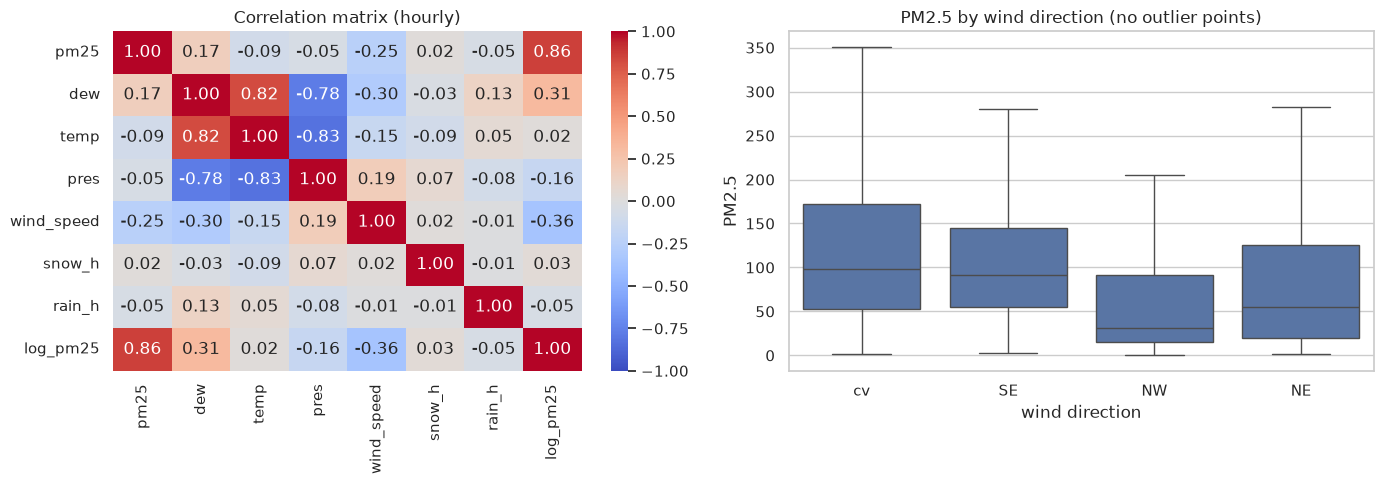

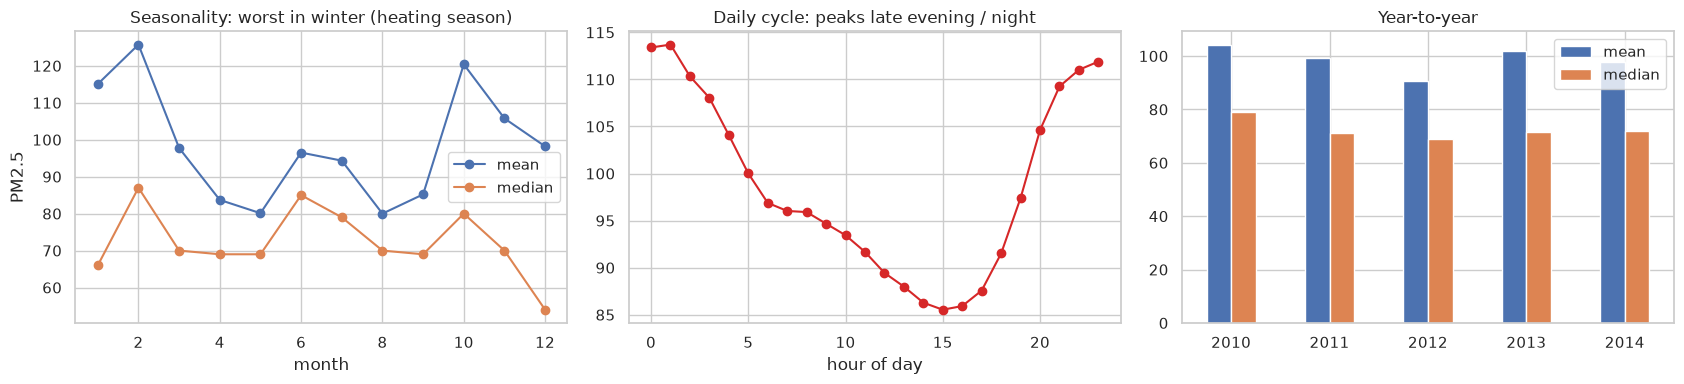

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(num.assign(log_pm25=np.log(num.pm25.clip(lower=1))).corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax[0]); ax[0].set_title("Correlation matrix (hourly)")
sns.boxplot(data=df.dropna(subset=["pm25"]), x="wind_dir", y="pm25", order=["cv", "SE", "NW", "NE"], showfliers=False, ax=ax[1]); ax[1].set(title="PM2.5 by wind direction (no outlier points)", xlabel="wind direction", ylabel="PM2.5")
plt.tight_layout(); plt.show()

d = df.assign(month=df.index.month, hour=df.index.hour, year=df.index.year)
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
d.groupby("month")["pm25"].agg(["mean", "median"]).plot(ax=ax[0], marker="o"); ax[0].set(title="Seasonality: worst in winter (heating season)", xlabel="month", ylabel="PM2.5")
d.groupby("hour")["pm25"].mean().plot(ax=ax[1], marker="o", color="tab:red"); ax[1].set(title="Daily cycle: peaks late evening / night", xlabel="hour of day")
d.groupby("year")["pm25"].agg(["mean", "median"]).plot.bar(ax=ax[2], rot=0); ax[2].set(title="Year-to-year", xlabel="")
plt.tight_layout(); plt.show()

### From hourly to daily: the table used in the rest of the course
Weeks 2–5 work with **one row per day** (1,826 days; 1,753 with a usable PM2.5 mean). Weather inputs are daily summaries; the target is the daily mean PM2.5, which is turned into a 4-class air-quality label
(**Good** ≤ 35, **Moderate** ≤ 75, **Unhealthy** ≤ 150, **Very unhealthy** > 150 µg/m³) and a binary label **polluted** (> 75 µg/m³).

,pm25,pm25_max,dew,temp,pres,temp_range,pres_range,dew_range,wind_speed,snow_h,...,calm_frac,wind_dir,log_wind,month,year,dayofyear,season,log_pm25,aqi_class,polluted
datetime,,,,,,,,,,,,,,,,,,,,,
2010-01-01,NaN,NaN,-18.750000,-6.750000,1017.083333,13.0,7.0,4,43.82,0,...,0.125000,NW,3.802654,1,2010,1,winter,NaN,NaN,NaN
2010-01-02,145.958333,181.0,-8.500000,-5.125000,1024.750000,2.0,8.0,9,55.43,4,...,0.000000,SE,4.033001,1,2010,2,winter,4.983321,Unhealthy,1.0
2010-01-03,78.833333,107.0,-10.125000,-8.541667,1022.791667,5.0,7.0,5,127.84,27,...,0.083333,SE,4.858571,1,2010,3,winter,4.367336,Unhealthy,1.0
2010-01-04,31.333333,79.0,-20.875000,-11.500000,1029.291667,6.0,12.0,12,198.45,0,...,0.000000,NW,5.295564,1,2010,4,winter,3.444682,Good,0.0
2010-01-05,42.458333,106.0,-24.583333,-14.458333,1033.625000,8.0,4.0,5,218.57,0,...,0.041667,NW,5.391671,1,2010,5,winter,3.748523,Moderate,0.0


rows: 1826 | with PM2.5: 1753

class balance:
                days  share
aqi_class                  
Good             361  0.206
Moderate         470  0.268
Unhealthy        572  0.326
Very unhealthy   350  0.200
polluted days (>75): 52.6%


,dew,temp,pres,wind_speed,rain_h,calm_frac
aqi_class,,,,,,
Good,-5.75,10.57,1019.48,115.92,0.87,0.12
Moderate,1.11,12.86,1016.47,58.05,1.01,0.20
Unhealthy,6.15,14.98,1014.10,43.35,1.20,0.24
Very unhealthy,3.26,9.56,1017.02,29.91,0.62,0.30


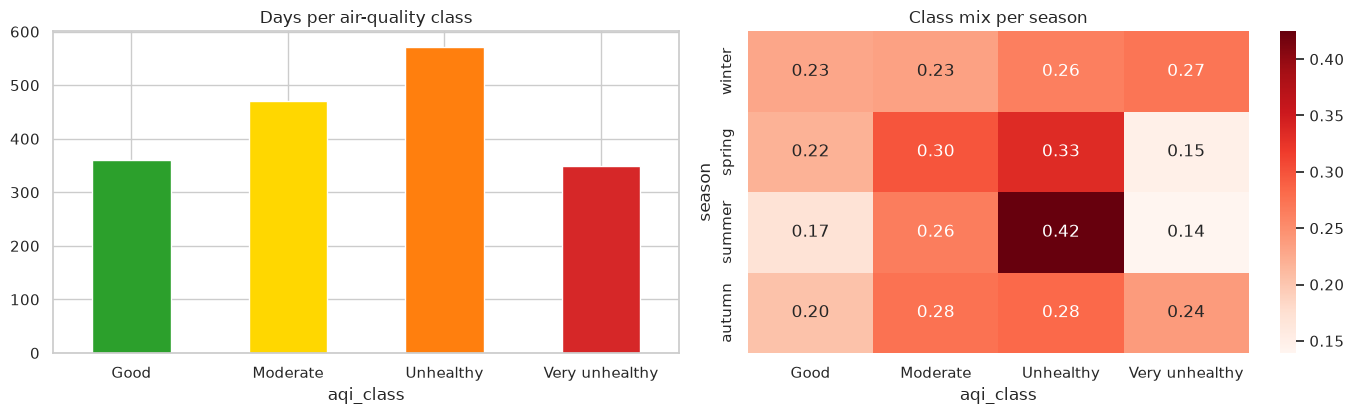

In [22]:
display(daily.head()); print("rows:", len(daily), "| with PM2.5:", daily["pm25"].notna().sum())
v = daily.dropna(subset=["pm25"])
print("\nclass balance:"); print(pd.concat([v["aqi_class"].value_counts(sort=False), v["aqi_class"].value_counts(normalize=True, sort=False).round(3)], axis=1, keys=["days", "share"]).to_string())
print(f"polluted days (>75): {v.polluted.mean():.1%}")
display(v.groupby("aqi_class", observed=True)[["dew", "temp", "pres", "wind_speed", "rain_h", "calm_frac"]].mean().round(2))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.3))
v["aqi_class"].value_counts(sort=False).plot.bar(ax=ax[0], rot=0, color=["tab:green", "gold", "tab:orange", "tab:red"]); ax[0].set_title("Days per air-quality class")
sns.heatmap(pd.crosstab(v["season"], v["aqi_class"], normalize="index").reindex(["winter", "spring", "summer", "autumn"]), annot=True, fmt=".2f", cmap="Reds", ax=ax[1]); ax[1].set_title("Class mix per season")
plt.tight_layout(); plt.show()

## Summary
* Learned the supervised / unsupervised distinction and saw over-fitting & regularisation, both on a synthetic curve and on the real annual temperature cycle.
* Verified Bayes' rule on a medical test *and* on Beijing pollution data; saw (conditional) dependence, quantiles, the log-normal nature of PM2.5, and covariance of weather variables.
* Imported, cleaned and viewed a real dataset; wrote a reusable summary routine; analysed missing data, skewness, seasonality and the daily table used in all later weeks.